# Artificial Neural Network (ANN) — Iris Flower Classification

**Goal:** Build, train, and evaluate a multi-layer ANN using TensorFlow/Keras to classify the Iris dataset into 3 species: *Setosa*, *Versicolor*, and *Virginica*.

**Notebook Structure:**
1. Library Imports & Setup
2. Data Loading & Exploration
3. Data Preprocessing
4. Model Architecture
5. Training
6. Evaluation & Visualisation
7. Confusion Matrix & Classification Report
8. Prediction on Unseen Data
9. Model Saving & Loading


## 1. Library Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
import random
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)


TensorFlow version: 2.21.0
NumPy version: 2.5.0


## 2. Data Loading & Exploration

The **Iris dataset** contains 150 samples across 3 species with 4 numerical features each.


In [2]:
# Load dataset
iris = load_iris()
X = iris.data        # Features: (150, 4)
y = iris.target      # Labels:   (150,)

print('Features shape:', X.shape)
print('Labels shape  :', y.shape)
print('Feature names :', iris.feature_names)
print('Target names  :', list(iris.target_names))


Features shape: (150, 4)
Labels shape  : (150,)
Feature names : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names  : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [3]:
# Build a readable DataFrame
df = pd.DataFrame(X, columns=iris.feature_names)
df['target']  = y
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

print(df.head(10))
print()
print('Dataset shape:', df.shape)


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   
9                4.9               3.1                1.5               0.1   

   target species  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  
5       0 

In [4]:
# Basic statistics
print('=== Descriptive Statistics ===')
print(df.describe().round(3))


=== Descriptive Statistics ===
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count            150.000           150.000            150.000   
mean               5.843             3.057              3.758   
std                0.828             0.436              1.765   
min                4.300             2.000              1.000   
25%                5.100             2.800              1.600   
50%                5.800             3.000              4.350   
75%                6.400             3.300              5.100   
max                7.900             4.400              6.900   

       petal width (cm)   target  
count           150.000  150.000  
mean              1.199    1.000  
std               0.762    0.819  
min               0.100    0.000  
25%               0.300    0.000  
50%               1.300    1.000  
75%               1.800    2.000  
max               2.500    2.000  


In [5]:
# Data quality check
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Duplicate Rows ===', df.duplicated().sum())
print()
print('=== Class Distribution ===')
print(df['species'].value_counts())


=== Missing Values ===
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

=== Duplicate Rows === 1

=== Class Distribution ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


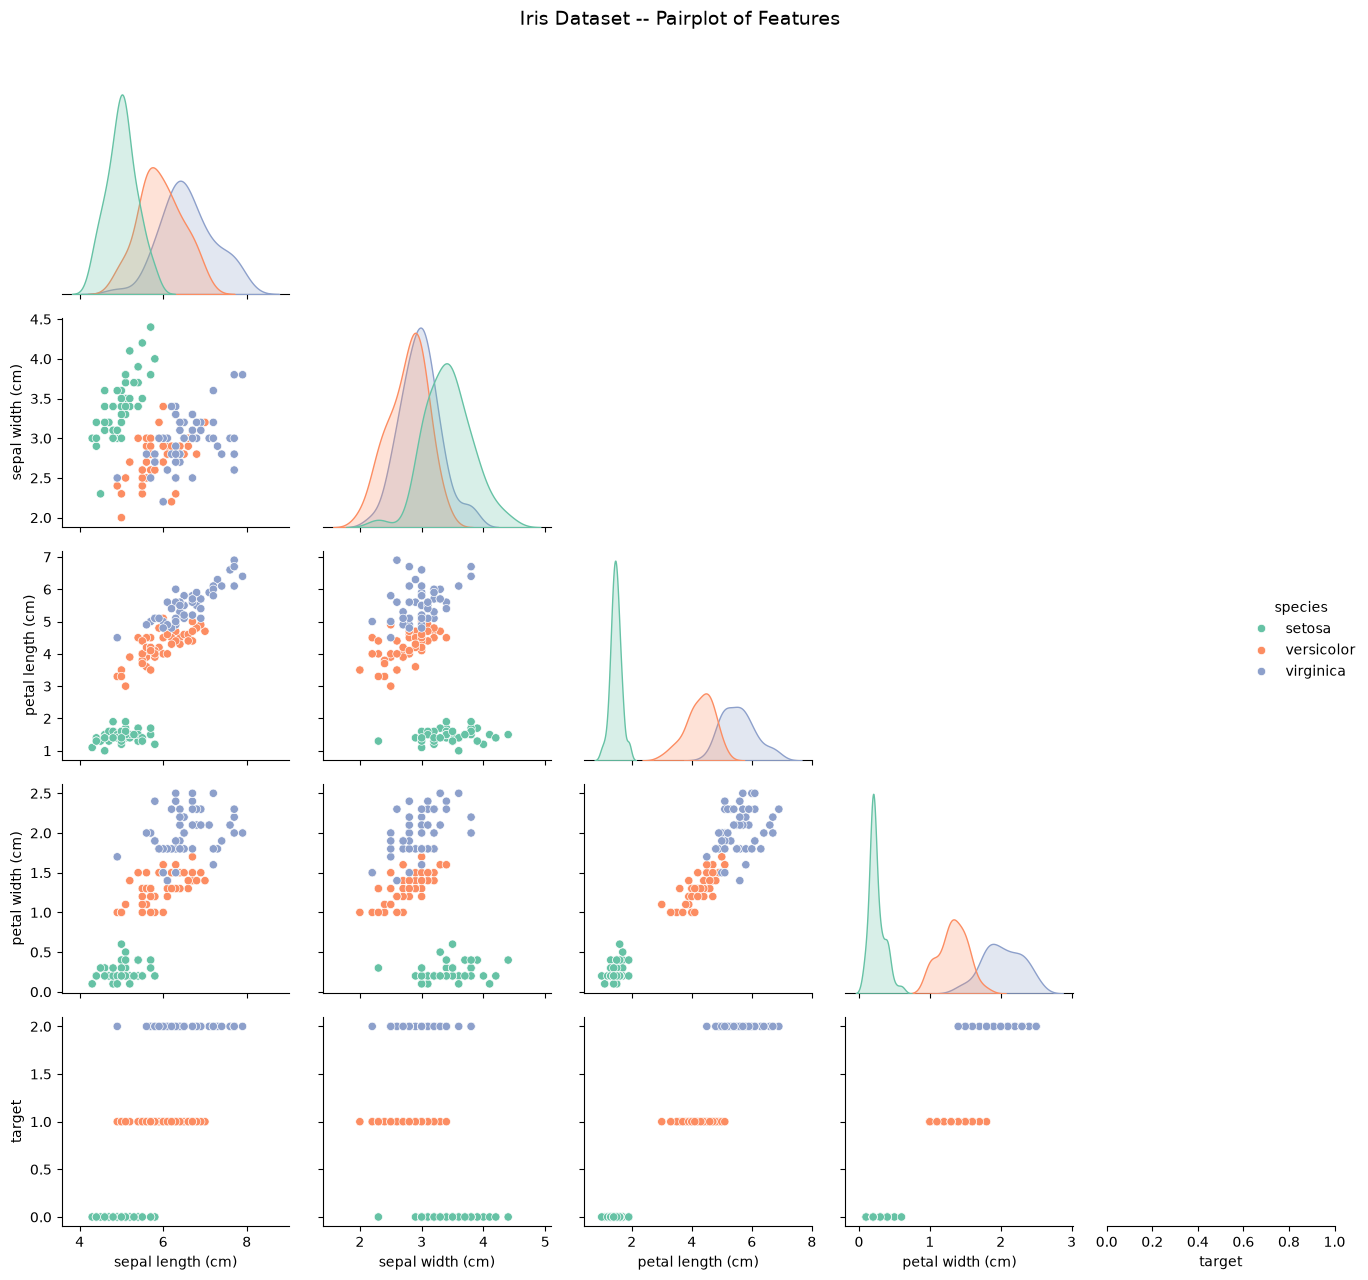

In [6]:
# Pairplot -- visualise feature relationships
sns.pairplot(df, hue='species', palette='Set2', diag_kind='kde', corner=True)
plt.suptitle('Iris Dataset -- Pairplot of Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


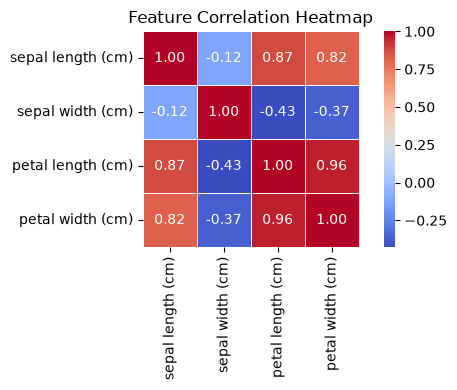

In [7]:
# Correlation heatmap
plt.figure(figsize=(6, 4))
corr = df[iris.feature_names].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


## 3. Data Preprocessing

Steps:
- **StandardScaler** -- zero-mean, unit-variance scaling so no feature dominates
- **One-hot encoding** -- convert integer labels to categorical vectors for softmax output
- **Train/Test split** -- 80% train, 20% test (stratified to preserve class balance)


In [8]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Before scaling -- mean:', X.mean(axis=0).round(3))
print('After  scaling -- mean:', X_scaled.mean(axis=0).round(3))
print('After  scaling -- std :', X_scaled.std(axis=0).round(3))


Before scaling -- mean: [5.843 3.057 3.758 1.199]
After  scaling -- mean: [-0. -0. -0. -0.]
After  scaling -- std : [1. 1. 1. 1.]


In [9]:
# One-hot encode labels
y_encoded = tf.keras.utils.to_categorical(y, num_classes=3)
print('Label shape after encoding:', y_encoded.shape)
print('First 5 encoded labels:')
print(y_encoded[:5])


Label shape after encoding: (150, 3)
First 5 encoded labels:
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [10]:
# Train / Test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=SEED,
    stratify=y          # preserve class proportions
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')


Training samples : 120
Test samples     : 30


## 4. Model Architecture

| Layer | Units | Activation | Notes |
|-------|-------|-----------|-------|
| Input + Dense 1 | 16 | ReLU | Captures primary patterns |
| Dropout | -- | -- | Regularisation (20% dropout) |
| Dense 2 | 8 | ReLU | Refines representations |
| Output | 3 | Softmax | Probability per class |


In [11]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(4,), name='hidden_1'),
    Dropout(0.2, name='dropout_1'),    # reduces overfitting
    Dense(8,  activation='relu',       name='hidden_2'),
    Dense(3,  activation='softmax',    name='output')   # 3-class probabilities
], name='ANN_Iris_Classifier')

model.summary()


/opt/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "ANN_Iris_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


## 5. Model Training

- **EarlyStopping** -- stops training if validation loss stops improving (patience = 10 epochs)
- **Validation split** -- 20% of training data used for live validation each epoch


In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2604 - loss: 1.1437 - val_accuracy: 0.3750 - val_loss: 1.1032
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3021 - loss: 1.1639 - val_accuracy: 0.4167 - val_loss: 1.0747
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3854 - loss: 1.0700 - val_accuracy: 0.4167 - val_loss: 1.0476
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4479 - loss: 1.0504 - val_accuracy: 0.5000 - val_loss: 1.0148
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4896 - loss: 1.0508 - val_accuracy: 0.6250 - val_loss: 0.9820
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5521 - loss: 1.0026 - val_accuracy: 0.7083 - val_loss: 0.9504
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6458 - loss: 0.9692 - val_accuracy: 0.7917 - val_loss: 0.9176
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7604 - loss: 0.9234 - val_accuracy: 0.8750 - v

## 6. Evaluation & Visualisation


In [14]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss     : {loss:.4f}')
print(f'Test Accuracy : {accuracy * 100:.2f}%')


Test Loss     : 0.1291
Test Accuracy : 93.33%


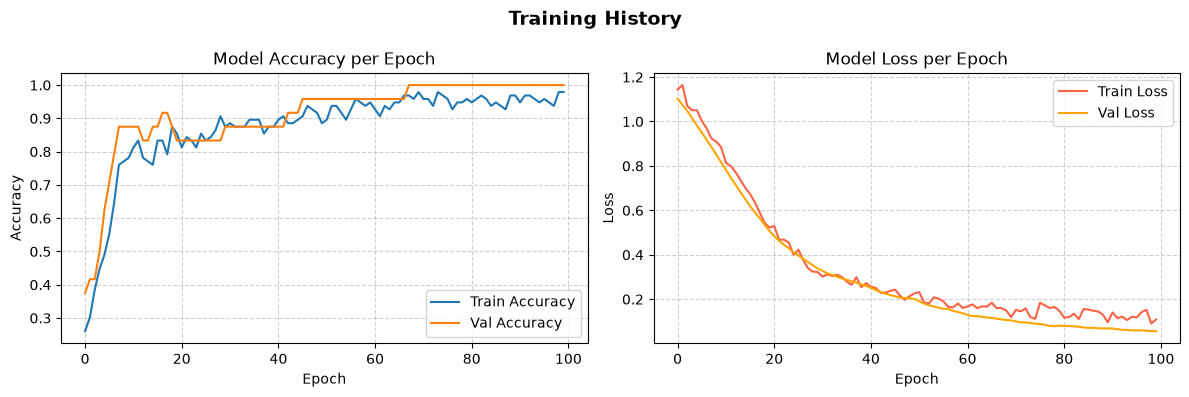

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Model Accuracy per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss', color='tomato')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[1].set_title('Model Loss per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Confusion Matrix & Classification Report


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


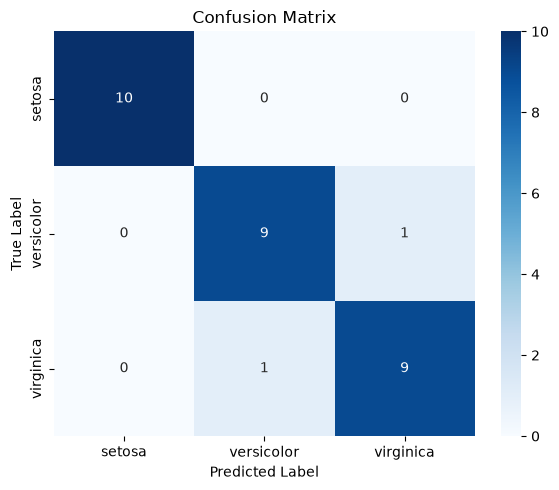


=== Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [16]:
# Generate predictions
y_pred_probs   = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test,       axis=1)

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print('\n=== Classification Report ===')
print(classification_report(y_true_classes, y_pred_classes,
                             target_names=iris.target_names))


## 8. Prediction on Unseen Data

Testing the model on 4 hand-crafted samples that were **never seen during training**.


In [17]:
# Unseen samples (sepal length, sepal width, petal length, petal width)
unseen_data = pd.DataFrame([
    [5.1, 3.5, 1.4, 0.2],   # likely Setosa
    [6.2, 3.4, 5.4, 2.3],   # likely Virginica
    [5.9, 3.0, 4.2, 1.5],   # likely Versicolor
    [6.0, 2.2, 4.0, 1.0],   # borderline case
], columns=iris.feature_names)

# Scale using the SAME scaler fitted on training data
unseen_scaled = scaler.transform(unseen_data)

# Predict
pred_probs   = model.predict(unseen_scaled)
pred_classes = np.argmax(pred_probs, axis=1)
pred_labels  = [iris.target_names[i] for i in pred_classes]
confidence   = np.max(pred_probs, axis=1) * 100

unseen_data['Predicted Class']   = pred_classes
unseen_data['Predicted Species'] = pred_labels
unseen_data['Confidence (%)']    = confidence.round(2)

print(unseen_data.to_string(index=False))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  Predicted Class Predicted Species  Confidence (%)
               5.1               3.5                1.4               0.2                0            setosa       99.989998
               6.2               3.4                5.4               2.3                2         virginica       98.330002
               5.9               3.0                4.2               1.5                1        versicolor       85.110001
               6.0               2.2                4.0               1.0                1        versicolor       99.699997


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


## 9. Model Saving & Loading

Save the trained model so it can be reloaded without retraining.


In [18]:
# Save model
model.save('iris_ann_model.keras')
print('Model saved to iris_ann_model.keras')

# Reload and verify
loaded_model = load_model('iris_ann_model.keras')
_, loaded_acc = loaded_model.evaluate(X_test, y_test, verbose=0)
print(f'Loaded model test accuracy: {loaded_acc * 100:.2f}%')


Model saved to iris_ann_model.keras
Loaded model test accuracy: 93.33%


---
## Summary

| Item | Detail |
|------|--------|
| Dataset | Iris (150 samples, 4 features, 3 classes) |
| Preprocessing | StandardScaler + One-hot encoding + Stratified split |
| Architecture | Dense(16, ReLU) -> Dropout(0.2) -> Dense(8, ReLU) -> Dense(3, Softmax) |
| Optimiser | Adam |
| Loss | Categorical Cross-Entropy |
| Regularisation | Dropout + EarlyStopping |
| Metric | Accuracy |

> **Expected accuracy: ~96-100% on test set**, which is typical for this well-separable dataset.
